# Evaluate Eval Models using MedEvidence Data 

Only evaluate the questions that do not need full text


In [4]:
from utils import render_prompt
import pandas as pd
from models.gemini import Gemini
from models.gpt5 import GPT5
from utils import load_json_file, save_dataset_to_json, load_jsonl_file
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import Entrez
import ast
from tqdm import tqdm
import json


Entrez.email = 'yun.hy@northeastern.edu'
EVAL_MODEL_TEMPERATURE = 0.0
EVIDENCE_DIRECTION_PROMPT_TEMPLATE_NAMES = "evidence_direction_question"

In [ ]:
# load medevidence dataset
medevidence_file_path = "../data/MedEvidence/medEvidence.csv"
medevidence_df = pd.read_csv(medevidence_file_path)

medevidence_df.shape

(284, 11)

In [22]:
# filter out rows where fulltext_required is yes. Only keep rows where fulltext_required is no
filtered_medevidence_df = medevidence_df[medevidence_df['fulltext_required'] == 'no']
filtered_medevidence_df.shape

(216, 11)

In [23]:
def get_abstract(pmid):
    try:
        # Fetch the record from the 'pubmed' database in XML format
        handle = Entrez.efetch(db="pubmed", id=pmid, retmode="xml")
        records = Entrez.read(handle)
        handle.close()

        # Drill down into the XML structure to find the abstract
        # Note: Some articles may not have an abstract
        article = records['PubmedArticle'][0]['MedlineCitation']['Article']
        
        if 'Abstract' in article:
            # Abstracts can be split into multiple sections (Background, Methods, etc.)
            abstract_list = article['Abstract']['AbstractText']
            return " ".join(abstract_list)
        else:
            return "Abstract not available for this PMID."

    except Exception as e:
        return f"Error: {str(e)}"

In [24]:
# format data for model evaluation
data = filtered_medevidence_df.to_dict(orient='records')
formatted_input_for_model_evaluator = {}
for row in tqdm(data):
    question = row['question']
    sources = ast.literal_eval(row['sources'])
    question_id = row['question_id']

    new_sources = []
    for pmid, source in sources.items():
        abstract = get_abstract(pmid) # this is needed since not all the content in the dataset is just abstracts. some are full text which is not what we want.
        if abstract.startswith("Error:") or abstract == "Abstract not available for this PMID.":
            print(f"Warning: Could not retrieve abstract for PMID {pmid}. Skipping this source.")
            continue
        new_sources.append({"article_id": pmid, "summary": abstract})

    eval_direction_input = render_prompt(EVIDENCE_DIRECTION_PROMPT_TEMPLATE_NAMES, template_dir="./prompts", question=question, context=new_sources)
    formatted_input_for_model_evaluator[f"{question_id}"] = eval_direction_input

100%|██████████| 216/216 [02:57<00:00,  1.22it/s]


In [ ]:
# save formatted input for model evaluator to jsonl file
formatted_input_list = [{"question_id": question_id, "input": input} for question_id, input in formatted_input_for_model_evaluator.items()]
save_dataset_to_json(formatted_input_list, "../data/MedEvidence/medevidence_formatted_eval_input.jsonl", jsonl=True)

In [ ]:
formatted_input_list = load_jsonl_file("../data/MedEvidence/medevidence_formatted_eval_input.jsonl")
formatted_input_for_model_evaluator = {item['question_id']: item['input'] for item in formatted_input_list}

In [ ]:
# formatted_input_for_model_evaluator

## Submit Batch Job to Model

### Submit to Gemini

In [3]:
from google import genai
from dotenv import load_dotenv
import os

load_dotenv(override=True)
gemini_api_key = os.getenv("GEMINI_API_KEY")
gemini_client = genai.Client(api_key=gemini_api_key)

# gemini counting tokens
total_tokens = 0
for question_id, input in formatted_input_for_model_evaluator.items():
    response = gemini_client.models.count_tokens(
        model="gemini-2.5-flash",
        contents=input,
    )
    total_tokens += response.total_tokens
print("Total number of tokens in formatted input for model evaluator :", total_tokens)

Total number of tokens in formatted input for model evaluator : 256382


In [ ]:
# load the evaluation model
eval_model = Gemini("pro")

# eval_model.submit_batch(formatted_input_for_model_evaluator, EVAL_MODEL_TEMPERATURE)

Uploaded batch input file: files/tt5wuckc9am8
Created batch: batches/lpdukx9hdgyy84t7x8wz20wmmuly4ss9taov


'batches/lpdukx9hdgyy84t7x8wz20wmmuly4ss9taov'

In [ ]:
# load the evaluation model
eval_model = Gemini("flash")

# eval_model.submit_batch(formatted_input_for_model_evaluator, EVAL_MODEL_TEMPERATURE)

Uploaded batch input file: files/d75bu8fr2ula
Created batch: batches/ok4hikkr1icixo1w2kj8235z45urvkn2s7nb


'batches/ok4hikkr1icixo1w2kj8235z45urvkn2s7nb'

In [ ]:
# load the evaluation model
eval_model = Gemini("lite")

# eval_model.submit_batch(formatted_input_for_model_evaluator, EVAL_MODEL_TEMPERATURE)

Uploaded batch input file: files/ti7pe9u5eq9w
Created batch: batches/zqnmnc3dhvuigpcbesqgaxllc5qyuhcd7iag


'batches/zqnmnc3dhvuigpcbesqgaxllc5qyuhcd7iag'

### Submit to GPT 5

In [ ]:
# load the evaluation model
eval_model = GPT5("mini")

eval_model.submit_batch(formatted_input_for_model_evaluator, EVAL_MODEL_TEMPERATURE)

Uploaded batch input file: FileObject(id='file-UopGMjRaMD4dwdQutu9jgv', bytes=1090198, created_at=1772165961, filename='gpt-5-mini-2025-08-07_batch_20260226_231920.jsonl', object='file', purpose='batch', status='processed', expires_at=1774757961, status_details=None)
Created batch: Batch(id='batch_69a11b4a003c8190afe775ad8ddba928', completion_window='24h', created_at=1772165962, endpoint='/v1/responses', input_file_id='file-UopGMjRaMD4dwdQutu9jgv', object='batch', status='validating', cancelled_at=None, cancelling_at=None, completed_at=None, error_file_id=None, errors=None, expired_at=None, expires_at=1772252362, failed_at=None, finalizing_at=None, in_progress_at=None, metadata=None, model=None, output_file_id=None, request_counts=BatchRequestCounts(completed=0, failed=0, total=0), usage=BatchUsage(input_tokens=0, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=0, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=0))


'batch_69a11b4a003c8190afe775ad8ddba928'

In [ ]:
# load the evaluation model
eval_model = GPT5("nano")

eval_model.submit_batch(formatted_input_for_model_evaluator, EVAL_MODEL_TEMPERATURE)

Uploaded batch input file: FileObject(id='file-RwmLo2csZAc4DjDjV7XRTn', bytes=1090198, created_at=1772165968, filename='gpt-5-nano-2025-08-07_batch_20260226_231927.jsonl', object='file', purpose='batch', status='processed', expires_at=1774757968, status_details=None)
Created batch: Batch(id='batch_69a11b50fa4c81908750663f986a3c5e', completion_window='24h', created_at=1772165968, endpoint='/v1/responses', input_file_id='file-RwmLo2csZAc4DjDjV7XRTn', object='batch', status='validating', cancelled_at=None, cancelling_at=None, completed_at=None, error_file_id=None, errors=None, expired_at=None, expires_at=1772252368, failed_at=None, finalizing_at=None, in_progress_at=None, metadata=None, model=None, output_file_id=None, request_counts=BatchRequestCounts(completed=0, failed=0, total=0), usage=BatchUsage(input_tokens=0, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=0, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=0))


'batch_69a11b50fa4c81908750663f986a3c5e'

## Get results

### GEMINI

In [101]:
from google import genai
from dotenv import load_dotenv
import os

load_dotenv(override=True)
gemini_api_key = os.getenv("GEMINI_API_KEY")
gemini_client = genai.Client(api_key=gemini_api_key)

In [111]:
# BATCH_ID = "batches/lpdukx9hdgyy84t7x8wz20wmmuly4ss9taov" # PRO
# BATCH_ID = "batches/zqnmnc3dhvuigpcbesqgaxllc5qyuhcd7iag" # LITE
BATCH_ID = "batches/ok4hikkr1icixo1w2kj8235z45urvkn2s7nb" # FLASH

In [112]:
print(f"Retrieving status for job: {BATCH_ID}")

batch_job = gemini_client.batches.get(name=BATCH_ID)
print(f"Current state: {batch_job.state.name}")
print(f"Job details: {batch_job}")

Retrieving status for job: batches/ok4hikkr1icixo1w2kj8235z45urvkn2s7nb
Current state: JOB_STATE_PENDING
Job details: name='batches/ok4hikkr1icixo1w2kj8235z45urvkn2s7nb' display_name=None state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'> error=None create_time=datetime.datetime(2026, 2, 26, 11, 46, 28, 6013, tzinfo=TzInfo(UTC)) start_time=None end_time=None update_time=datetime.datetime(2026, 2, 26, 11, 46, 28, 6013, tzinfo=TzInfo(UTC)) model='models/gemini-2.5-flash' src=None dest=None completion_stats=None


In [76]:
def get_batch_results(batch_name: str) -> dict:
    """
    Fetches batch status and outputs (if completed)
    """
    batch_job = gemini_client.batches.get(name=batch_name)

    # The output is in another file.
    result_file_name = batch_job.dest.file_name
    print(f"Results are in file: {result_file_name}")

    print("\nDownloading and parsing result file content...")
    file_content_bytes = gemini_client.files.download(file=result_file_name)
    file_content = file_content_bytes.decode('utf-8')

    results = {}
    for line in file_content.splitlines():
        if line:
            record = json.loads(line)
            custom_id = record["key"]
            response = record["response"]["candidates"][0]
            output_text = response["content"]["parts"][0]["text"]
            results[custom_id] = output_text
    return results

In [ ]:
results = get_batch_results(BATCH_ID)

model_version = "lite" # NEED TO CHANGE BASED ON MODEL

save_dataset_to_json(results, f"../data/MedEvidence/medevidence_evaluation_results_{model_version}.json")

Results are in file: files/batch-zqnmnc3dhvuigpcbesqgaxllc5qyuhcd7iag



### GPT 5

In [ ]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv(override=True)
openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [ ]:
BATCH_ID = "batch_69a11b4a003c8190afe775ad8ddba928"
# BATCH_ID = "batch_69a11b50fa4c81908750663f986a3c5e"

In [ ]:
batch = openai_client.batches.retrieve(BATCH_ID)
print(batch)

Batch(id='batch_69a11b4a003c8190afe775ad8ddba928', completion_window='24h', created_at=1772165962, endpoint='/v1/responses', input_file_id='file-UopGMjRaMD4dwdQutu9jgv', object='batch', status='completed', cancelled_at=None, cancelling_at=None, completed_at=1772168117, error_file_id=None, errors=None, expired_at=None, expires_at=1772252362, failed_at=None, finalizing_at=1772168106, in_progress_at=1772166023, metadata=None, model='gpt-5-mini-2025-08-07', output_file_id='file-C5ug3Xj16jBEBziVwYP2da', request_counts=BatchRequestCounts(completed=216, failed=0, total=216), usage=BatchUsage(input_tokens=243711, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=155282, output_tokens_details=OutputTokensDetails(reasoning_tokens=96832), total_tokens=398993))


In [ ]:
def get_batch_results(batch_id: str) -> dict:
    """
    Fetches batch status and outputs (if completed)
    """
    batch = openai_client.batches.retrieve(batch_id)

    if batch.status != "completed":
        return {
            "status": batch.status,
            "message": "Batch not completed yet."
        }

    output_file_id = batch.output_file_id
    output_file = openai_client.files.content(output_file_id)

    results = {}
    for line in output_file.iter_lines():
        record = json.loads(line)
        custom_id = record["custom_id"]
        output_text = record["response"]["body"]["output"][1]["content"][0]["text"]
        results[custom_id] = output_text

    return results

In [ ]:
results = get_batch_results(BATCH_ID)

model_version = "gpt5-mini" # NEED TO CHANGE BASED ON MODEL
# model_version = "gpt5-nano" # NEED TO CHANGE BASED ON MODEL

save_dataset_to_json(results, f"../data/MedEvidence/medevidence_evaluation_results_{model_version}.json")

## Analyze Results

In [63]:
# model_versions = ["pro", "flash", "lite"]
model_versions = ["gemini2.5-pro", "gemini2.5-lite", "gpt5-mini", "gpt5-nano"]

model_results = {}

for model_version in model_versions:
    results = load_json_file(f"../data/MedEvidence/medevidence_evaluation_results_{model_version}.json")

    print(len(results))

    model_results[model_version] = results

216
216
216
216


In [ ]:
medevidence_file_path = "../data/MedEvidence/medEvidence.csv"
medevidence_df = pd.read_csv(medevidence_file_path)
filtered_medevidence_df = medevidence_df[medevidence_df['fulltext_required'] == 'no']
data = filtered_medevidence_df.to_dict(orient='records')

In [65]:
def extract_answer(text: str) -> str:
    """
    Extracts only nswer if answer exists else return the full text

    :param text: string of text

    :return: str
    """
    delimiter = "**Answer**:"
    parts = text.split(delimiter, 1)

    # If len is > 1, delimiter existed; return second part, stripped of whitespace
    if len(parts) > 1:
        return parts[1].strip().lower()

    return text.strip().lower()

In [66]:
for row in data:
    question_id = row['question_id']
    for model_version, results in model_results.items():
        if f"req-{question_id}" in results:
            response = results[f"req-{question_id}"]
            row[f"model_output_{model_version}"] = extract_answer(response)

In [67]:
# % of valid model output
# the output must be one of the following: higher, lower, no difference, insufficient data, uncertain effect
valid_outputs = {"higher", "lower", "no difference", "insufficient data", "uncertain effect"}

analysis_results = {}
for model_version in model_versions:
    analysis_results[model_version] = {}
    valid_count = 0
    for row in data:
        if f"model_output_{model_version}" in row and row[f"model_output_{model_version}"] in valid_outputs:
            valid_count += 1
        else: 
            print(f"Invalid output for question_id {row['question_id']} in model {model_version}: {row.get(f'model_output_{model_version}', 'No output')}")
    valid_pct = round(valid_count/len(data)*100, 2)
    print(f"Valid outputs for {model_version}: {valid_count}/{len(data)} ({valid_pct}%)")
    analysis_results[model_version]['valid_pct'] = valid_pct

Valid outputs for gemini2.5-pro: 216/216 (100.0%)
Invalid output for question_id 51 in model gemini2.5-lite: - **rationale**: the question asks to compare the response rate of cisplatin in combination with third-generation drugs versus carboplatin in combination with third-generation drugs. several articles provide this comparison. article [12928123] states the overall response rates were 41% for gemcitabine plus cisplatin (gp) and 29% for gemcitabine plus carboplatin (gc), indicating a higher response rate for gp. article [11784875] compares cisplatin and paclitaxel to carboplatin and paclitaxel, and states the response rate did not differ significantly. article [28643733] found response rates were comparable between gemcitabine/cisplatin and gemcitabine/carboplatin. article [12377641] found a response rate of 25% for paclitaxel/carboplatin and 28% for paclitaxel/cisplatin, with no significant difference. article [12826316] found an objective response rate of 41.9% for gemcitabine/cis

In [68]:
# % of accuracy of model output compared to the human answer which is the "answer" key in the dataset

for model_version in model_versions:
    accurate_count = 0
    for row in data:
        if f"model_output_{model_version}" in row and row[f"model_output_{model_version}"] == row["answer"]:
            accurate_count += 1

    accuracy_pct = round(accurate_count/len(data)*100, 2)
    print(f"Accurate outputs for {model_version}: {accurate_count}/{len(data)} ({accuracy_pct}%)")
    analysis_results[model_version]['accuracy_pct'] = accuracy_pct

Accurate outputs for gemini2.5-pro: 146/216 (67.59%)
Accurate outputs for gemini2.5-lite: 148/216 (68.52%)
Accurate outputs for gpt5-mini: 150/216 (69.44%)
Accurate outputs for gpt5-nano: 132/216 (61.11%)


In [69]:
# get the recall by each answer category for each model version
answer_categories = valid_outputs
all_recall_data = []

for model_version in model_versions:
    matrix_by_category = {category: {"tp": 0, "fn": 0} for category in answer_categories}
    for row in data:
        if f"model_output_{model_version}" in row and row["answer"] in answer_categories:
            human_answer = row["answer"]
            if row[f"model_output_{model_version}"] == human_answer:
                matrix_by_category[human_answer]["tp"] += 1
            else:
                matrix_by_category[human_answer]["fn"] += 1

    print(f"\nModel: {model_version}")
    for category, counts in matrix_by_category.items():
        tp = counts["tp"]
        fn = counts["fn"]
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        all_recall_data.append({"category": category, "recall": recall, "model": model_version})
        print(f"  Category: {category}, Recall: {recall:.2f} ({tp}/{tp + fn})")


Model: gemini2.5-pro
  Category: uncertain effect, Recall: 0.39 (9/23)
  Category: insufficient data, Recall: 0.74 (25/34)
  Category: lower, Recall: 0.76 (35/46)
  Category: higher, Recall: 0.77 (34/44)
  Category: no difference, Recall: 0.62 (43/69)

Model: gemini2.5-lite
  Category: uncertain effect, Recall: 0.17 (4/23)
  Category: insufficient data, Recall: 0.79 (27/34)
  Category: lower, Recall: 0.87 (40/46)
  Category: higher, Recall: 0.82 (36/44)
  Category: no difference, Recall: 0.59 (41/69)

Model: gpt5-mini
  Category: uncertain effect, Recall: 0.39 (9/23)
  Category: insufficient data, Recall: 0.76 (26/34)
  Category: lower, Recall: 0.78 (36/46)
  Category: higher, Recall: 0.75 (33/44)
  Category: no difference, Recall: 0.67 (46/69)

Model: gpt5-nano
  Category: uncertain effect, Recall: 0.22 (5/23)
  Category: insufficient data, Recall: 0.76 (26/34)
  Category: lower, Recall: 0.76 (35/46)
  Category: higher, Recall: 0.73 (32/44)
  Category: no difference, Recall: 0.49 (34

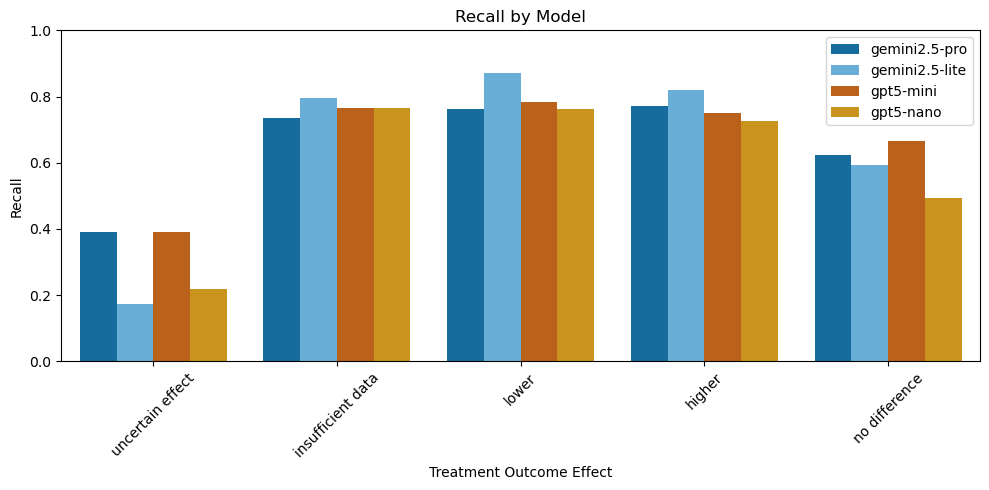

In [127]:
recall_df = pd.DataFrame(all_recall_data)

okabe_ito = ["#0072b2", "#56b3e9", "#d55e00", "#e69f00"]
plt.figure(figsize=(10, 5))
sns.barplot(x="category", y="recall", hue="model", data=recall_df, palette=okabe_ito)
plt.title("Recall by Model")
plt.xlabel("Treatment Outcome Effect")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title=None)
plt.tight_layout()
plt.show()

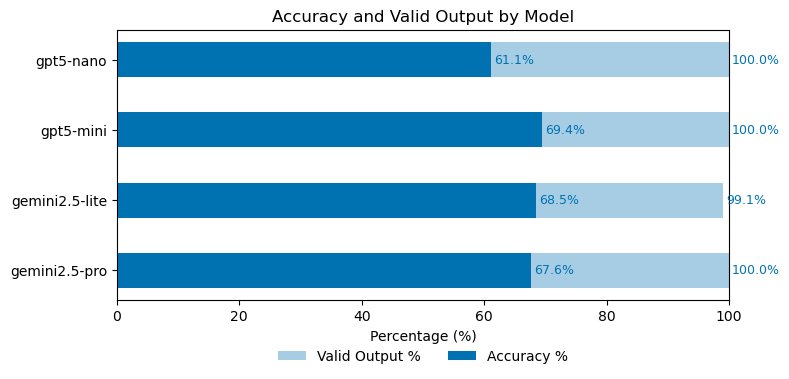

In [128]:
# Horizontal bullet chart: valid_pct as background bar, accuracy_pct overlaid in front
model_labels = model_versions
valid_vals = [analysis_results[m]["valid_pct"] for m in model_versions]
accuracy_vals = [analysis_results[m]["accuracy_pct"] for m in model_versions]

fig, ax = plt.subplots(figsize=(8, 4))
y = range(len(model_labels))
bar_height = 0.5

# Background bar: valid_pct (lighter)
ax.barh(y, valid_vals, height=bar_height, color="#0072b2", alpha=0.35, label="Valid Output %")
# Foreground bar: accuracy_pct (same width, darker)
ax.barh(y, accuracy_vals, height=bar_height, color="#0072b2", alpha=1.0, label="Accuracy %")

# Annotate each bar
for i, (v, a) in enumerate(zip(valid_vals, accuracy_vals)):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", ha="left", fontsize=9, color="#0072b2")
    ax.text(a + 0.5, i, f"{a:.1f}%", va="center", ha="left", fontsize=9, color="#0072b2")

ax.set_yticks(list(y))
ax.set_yticklabels(model_labels)
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage (%)")
ax.set_title("Accuracy and Valid Output by Model")
ax.legend()
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, -0.28), ncol=2, title=None, frameon=False,
)
plt.tight_layout()
plt.show()

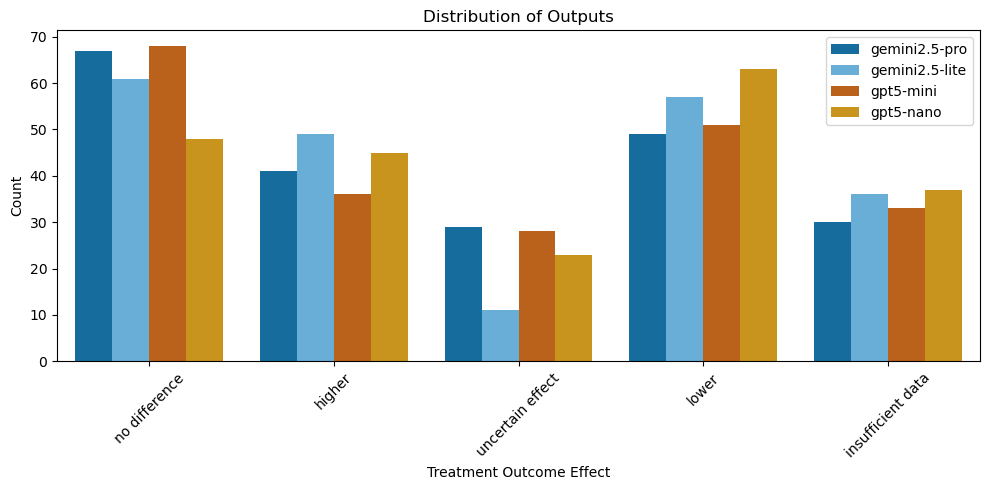

In [129]:
distribution_data = []
for model_version in model_versions:
    for row in data:
        if f"model_output_{model_version}" in row and row[f"model_output_{model_version}"] in valid_outputs:
            distribution_data.append({"category": row[f"model_output_{model_version}"], "model": model_version})

distribution_df = pd.DataFrame(distribution_data)

okabe_ito = ["#0072b2", "#56b3e9", "#d55e00", "#e69f00"]
plt.figure(figsize=(10, 5))
sns.countplot(x="category", hue="model", data=distribution_df, palette=okabe_ito)
plt.title("Distribution of Outputs")
plt.xlabel("Treatment Outcome Effect")
plt.ylabel("Count")
plt.legend(title=None)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

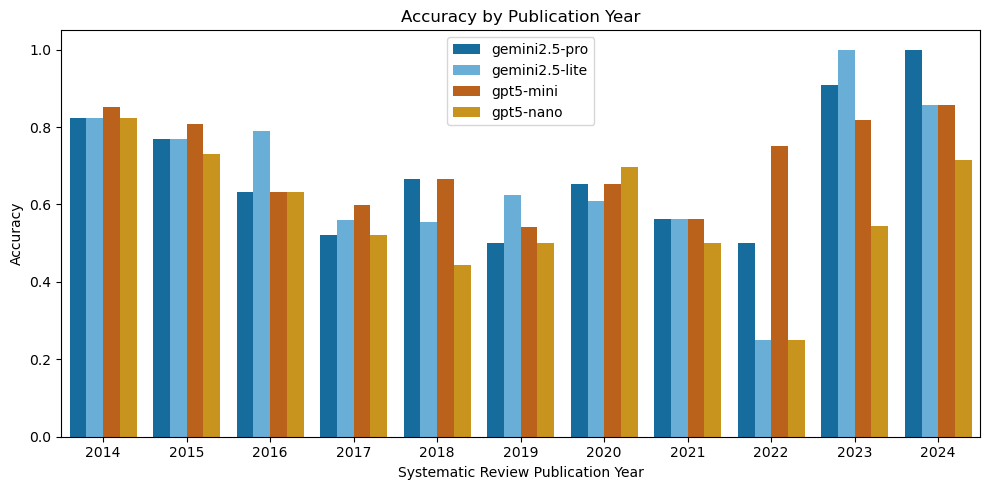

In [130]:
# seaborn bar plot of accuracy over time based on review_year, per model version
accuracy_by_year_data = []
for model_version in model_versions:
    accuracy_by_year = {}
    for row in data:
        if f"model_output_{model_version}" in row and row["answer"] in valid_outputs:
            review_year = row["review_year"]
            if review_year not in accuracy_by_year:
                accuracy_by_year[review_year] = {"tp": 0, "total": 0}
            accuracy_by_year[review_year]["total"] += 1
            if row[f"model_output_{model_version}"] == row["answer"]:
                accuracy_by_year[review_year]["tp"] += 1
    for year, counts in accuracy_by_year.items():
        accuracy_by_year_data.append({
            "review_year": year,
            "accuracy": counts["tp"] / counts["total"] if counts["total"] > 0 else 0.0,
            "model": model_version
        })

results_df = pd.DataFrame(accuracy_by_year_data)

okabe_ito = ["#0072b2", "#56b3e9", "#d55e00", "#e69f00"]
plt.figure(figsize=(10, 5))
sns.barplot(x="review_year", y="accuracy", hue="model", data=results_df, palette=okabe_ito)
plt.title("Accuracy by Publication Year")
plt.xlabel("Systematic Review Publication Year")
plt.ylabel("Accuracy")
plt.legend(title=None)
plt.tight_layout()
plt.show()

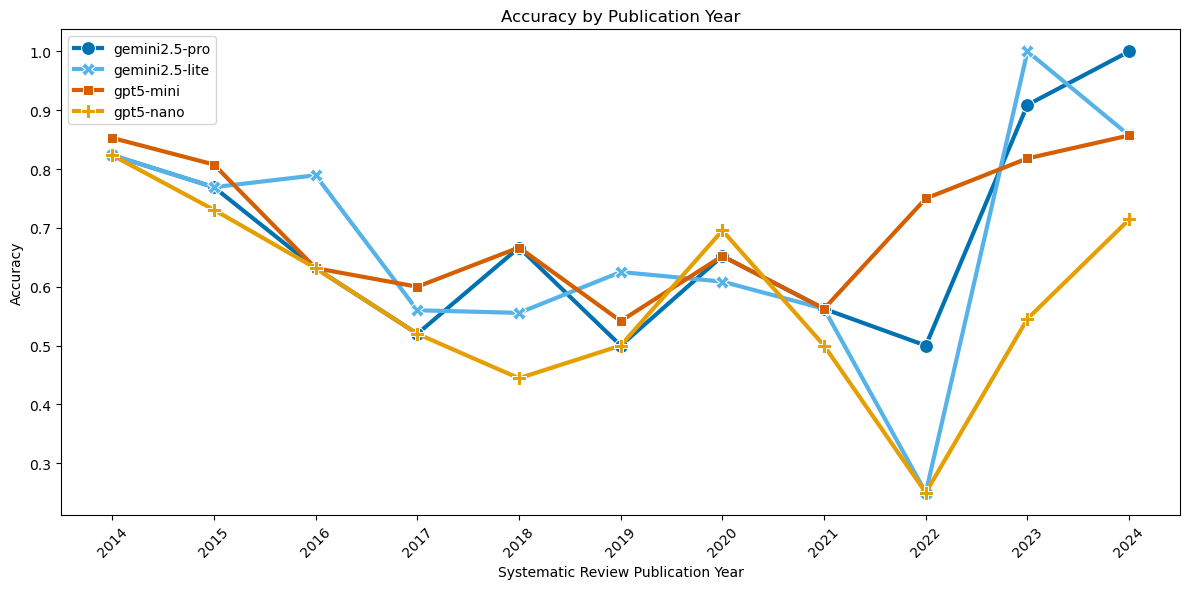

In [131]:
# seaborn line plot of accuracy over time based on review_year, per model version
accuracy_by_year_data = []
for model_version in model_versions:
    accuracy_by_year = {}
    for row in data:
        if f"model_output_{model_version}" in row and row["answer"] in valid_outputs:
            review_year = row["review_year"]
            if review_year not in accuracy_by_year:
                accuracy_by_year[review_year] = {"tp": 0, "total": 0}
            accuracy_by_year[review_year]["total"] += 1
            if row[f"model_output_{model_version}"] == row["answer"]:
                accuracy_by_year[review_year]["tp"] += 1
    for year, counts in accuracy_by_year.items():
        accuracy_by_year_data.append({
            "review_year": year,
            "accuracy": counts["tp"] / counts["total"] if counts["total"] > 0 else 0.0,
            "model": model_version
        })
results_df = pd.DataFrame(accuracy_by_year_data)
# Get a sorted list of all unique years in your data
unique_years = sorted(results_df['review_year'].unique())

plt.figure(figsize=(12, 6)) # Slightly wider to accommodate more labels

sns.lineplot(
    x="review_year", 
    y="accuracy", 
    hue="model", 
    style="model", 
    data=results_df, 
    palette=okabe_ito, 
    markers=True, 
    dashes=False,
    linewidth=3,
    markersize=10
)

# 2. Force Matplotlib to show every year
# 'rotation=45' keeps them readable if the list is long
plt.xticks(ticks=unique_years, labels=unique_years, rotation=45)

plt.title("Accuracy by Publication Year")
plt.xlabel("Systematic Review Publication Year")
plt.ylabel("Accuracy")
plt.legend(title=None)
plt.tight_layout()
plt.show()